In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import yfinance as yf
data=yf.download("AAPL",start="2018-01-01",end="2026-02-04")


[*********************100%***********************]  1 of 1 completed


In [3]:
print(data.tail(10))

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-01-21  247.649994  251.559998  245.179993  248.699997  54641700
2026-01-22  248.350006  251.000000  248.149994  249.199997  39708300
2026-01-23  248.039993  249.410004  244.679993  247.320007  41689000
2026-01-26  255.410004  256.559998  249.800003  251.479996  55969200
2026-01-27  258.269989  261.950012  258.209991  259.170013  49648300
2026-01-28  256.440002  258.859985  254.509995  257.649994  41288000
2026-01-29  258.279999  259.649994  254.410004  258.000000  67253000
2026-01-30  259.480011  261.899994  252.179993  255.169998  92443400
2026-02-02  270.010010  270.489990  259.209991  260.029999  73913400
2026-02-03  269.480011  271.880005  267.609985  269.200012  64339600


In [4]:
df=data.copy()

In [5]:
df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)

df.dropna(inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Lag1,Lag2,Lag3
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2018-01-05,40.983582,41.070231,40.526908,40.618243,94640000,40.522217,40.334858,40.341888
2018-01-08,40.831356,41.126437,40.732992,40.831356,82271200,40.983582,40.522217,40.334858
2018-01-09,40.826664,40.997623,40.611208,40.878186,86336000,40.831356,40.983582,40.522217
2018-01-10,40.817299,40.819643,40.515193,40.552665,95839600,40.826664,40.831356,40.983582
2018-01-11,41.049152,41.098334,40.864142,40.887559,74670800,40.817299,40.826664,40.831356


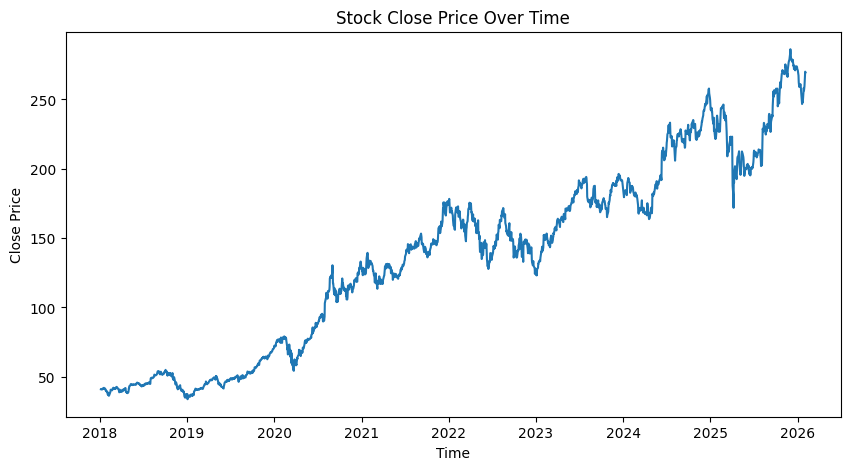

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.title("Stock Close Price Over Time")
plt.show()

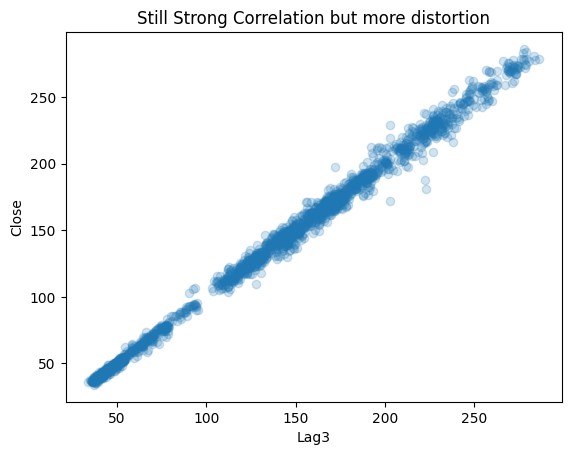

In [7]:
plt.scatter(df['Lag3'], df['Close'], alpha=0.2)
#alpha helps in managing the transparency level

plt.xlabel("Lag3")
plt.ylabel("Close")
plt.title("Still Strong Correlation but more distortion")
plt.show()

In [8]:
X=df[['Lag1','Lag2','Lag3']]
y=df['Close']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)



In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


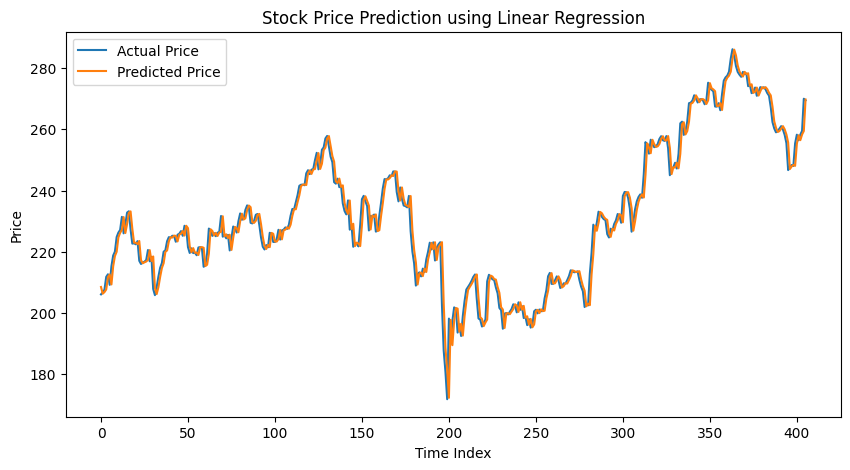

In [11]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.legend()
plt.title("Stock Price Prediction using Linear Regression")
plt.xlabel("Time Index")
plt.ylabel("Price")

plt.show()